In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
# Model Saving
import pickle

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [2]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

In [3]:
# Column information
print("=== COLUMN INFORMATION ===")
print(df.info())

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

=== COLUMN INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

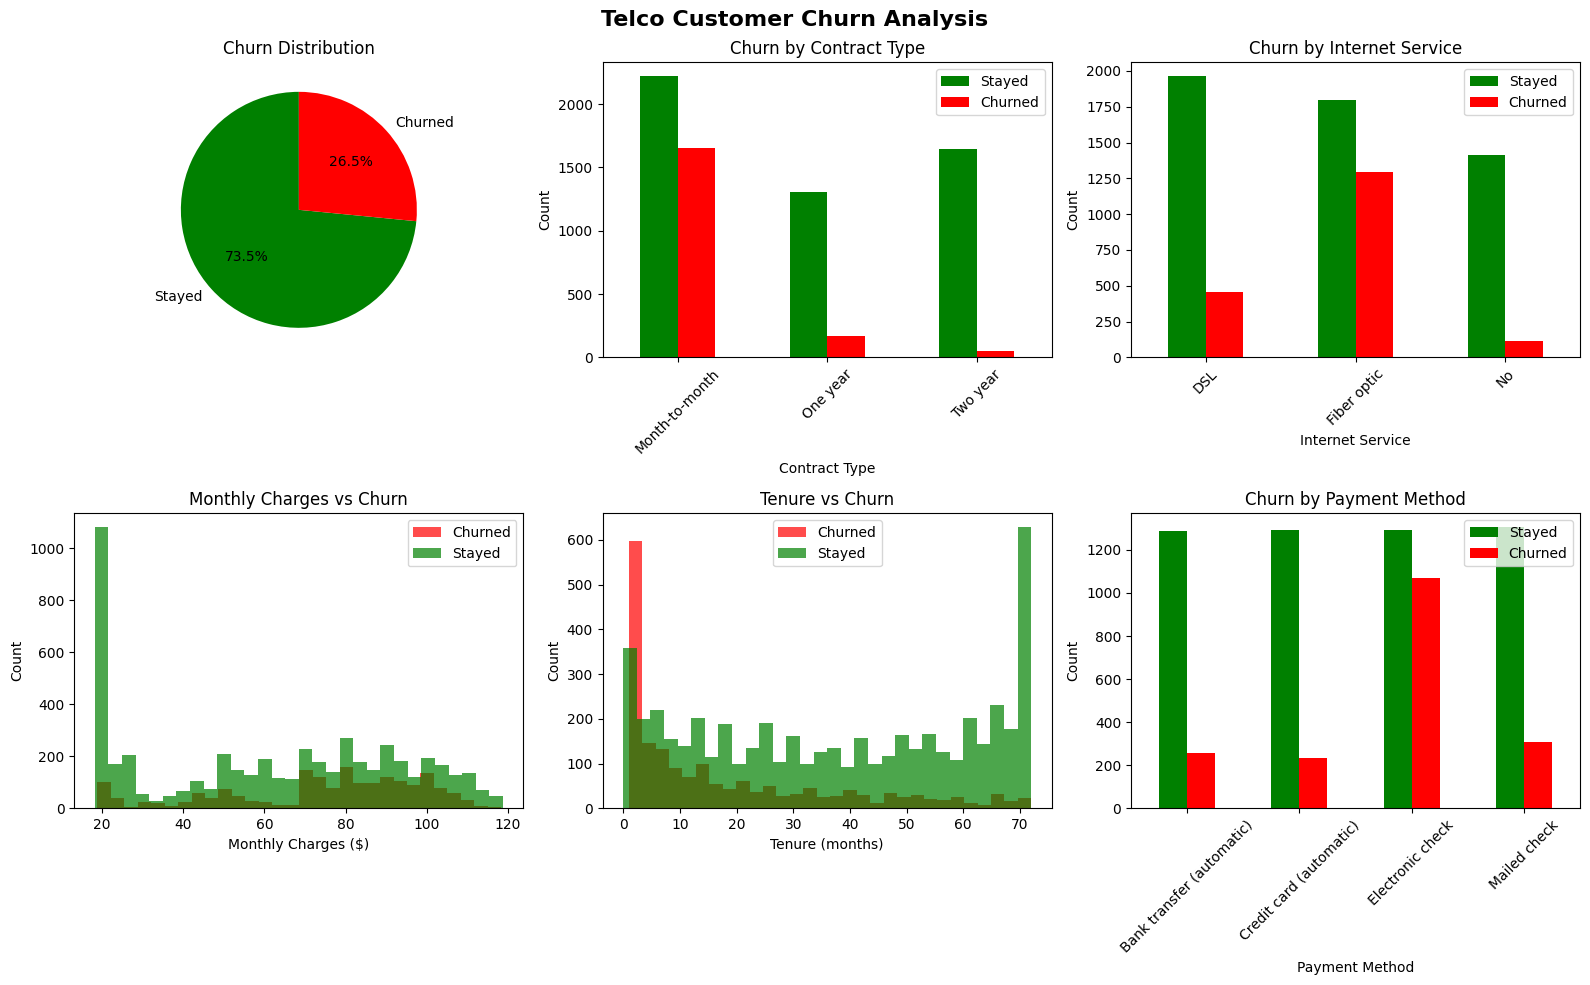

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telco Customer Churn Analysis',
             fontsize=16, fontweight='bold')

# Plot 1 - Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts,
              labels=['Stayed', 'Churned'],
              colors=['green', 'red'],
              autopct='%1.1f%%',
              startangle=90)
axes[0,0].set_title('Churn Distribution')

# Plot 2 - Churn by Contract Type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0,1],
                    color=['green', 'red'])
axes[0,1].set_title('Churn by Contract Type')
axes[0,1].set_xlabel('Contract Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(['Stayed', 'Churned'])

# Plot 3 - Churn by Internet Service
internet_churn = df.groupby(
    ['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[0,2],
                    color=['green', 'red'])
axes[0,2].set_title('Churn by Internet Service')
axes[0,2].set_xlabel('Internet Service')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].legend(['Stayed', 'Churned'])

# Plot 4 - Monthly Charges Distribution
axes[1,0].hist(df[df['Churn']=='Yes']['MonthlyCharges'],
               alpha=0.7, color='red',
               label='Churned', bins=30)
axes[1,0].hist(df[df['Churn']=='No']['MonthlyCharges'],
               alpha=0.7, color='green',
               label='Stayed', bins=30)
axes[1,0].set_title('Monthly Charges vs Churn')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Plot 5 - Tenure Distribution
axes[1,1].hist(df[df['Churn']=='Yes']['tenure'],
               alpha=0.7, color='red',
               label='Churned', bins=30)
axes[1,1].hist(df[df['Churn']=='No']['tenure'],
               alpha=0.7, color='green',
               label='Stayed', bins=30)
axes[1,1].set_title('Tenure vs Churn')
axes[1,1].set_xlabel('Tenure (months)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# Plot 6 - Churn by Payment Method
payment_churn = df.groupby(
    ['PaymentMethod', 'Churn']).size().unstack()
payment_churn.plot(kind='bar', ax=axes[1,2],
                   color=['green', 'red'])
axes[1,2].set_title('Churn by Payment Method')
axes[1,2].set_xlabel('Payment Method')
axes[1,2].set_ylabel('Count')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].legend(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

In [5]:
# Check unique values in Churn column
print("Churn values:", df['Churn'].unique())

# Check TotalCharges column
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)

# Fix TotalCharges - it's stored as text not number!
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce')

# Check for new missing values after conversion
print("\nMissing after conversion:",
      df['TotalCharges'].isnull().sum())

# Fill missing with median
df['TotalCharges'].fillna(
    df['TotalCharges'].median(), inplace=True)

print("TotalCharges fixed! ✅")

# Drop customerID - not useful for prediction
df = df.drop(columns=['customerID'])
print("customerID dropped! ✅")

print("\nDataset shape now:", df.shape)

Churn values: ['No' 'Yes']

TotalCharges dtype: object

Missing after conversion: 11
TotalCharges fixed! ✅
customerID dropped! ✅

Dataset shape now: (7043, 20)


/tmp/ipykernel_36204/361074017.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


In [6]:
# Check which columns are text/categorical
print("Categorical columns:")
categorical_cols = df.select_dtypes(
    include=['object']).columns.tolist()
print(categorical_cols)
print("Total categorical columns:", len(categorical_cols))

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Total categorical columns: 16


In [7]:
# Convert Churn to binary first (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn encoded: Yes=1, No=0 ✅")

# Convert all other categorical columns using dummies
df = pd.get_dummies(df, drop_first=True)

print("All categorical columns encoded! ✅")
print("\nNew dataset shape:", df.shape)
print("\nFirst 5 columns:", list(df.columns[:5]))
print("Last 5 columns:", list(df.columns[-5:]))

Churn encoded: Yes=1, No=0 ✅
All categorical columns encoded! ✅

New dataset shape: (7043, 31)

First 5 columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Last 5 columns: ['Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [8]:
# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)  # Ensures same churn ratio in train and test!

print("\nTraining size:", len(X_train))
print("Testing size:", len(X_test))
print("\nTrain churn distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True) * 100)

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Training size: 5634
Testing size: 1409

Train churn distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [9]:
# Scale features - important for Logistic Regression!
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully! ✅")
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Data scaled successfully! ✅
Training set shape: (5634, 30)
Testing set shape: (1409, 30)


In [10]:
# ================================
# MODEL 1: Logistic Regression
# ================================
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)  # Uses SCALED data!
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression trained! ✅")

# ================================
# MODEL 2: Decision Tree
# ================================
tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42)
tree.fit(X_train, y_train)  # Uses UNSCALED data!
tree_pred = tree.predict(X_test)
print("Decision Tree trained! ✅")

# ================================
# MODEL 3: Random Forest
# ================================
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    random_state=42)
rf.fit(X_train, y_train)  # Uses UNSCALED data!
rf_pred = rf.predict(X_test)
print("Random Forest trained! ✅")

print("\nAll models trained successfully! ✅")

Logistic Regression trained! ✅
Decision Tree trained! ✅
Random Forest trained! ✅

All models trained successfully! ✅


In [11]:
# Function to print all metrics neatly
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   output_dict=True)

    print(f"\n{'='*40}")
    print(f"MODEL: {name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {report['1']['precision']:.4f}")
    print(f"Recall:    {report['1']['recall']:.4f}")
    print(f"F1 Score:  {report['1']['f1-score']:.4f}")
    print(f"{'='*40}")

    return {
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'F1 Score': round(report['1']['f1-score'], 4)
    }

# Evaluate all models
results = []
results.append(evaluate_model(
    'Logistic Regression', y_test, lr_pred))
results.append(evaluate_model(
    'Decision Tree', y_test, tree_pred))
results.append(evaluate_model(
    'Random Forest', y_test, rf_pred))

# Create results table
results_df = pd.DataFrame(results)
print("\n=== FINAL COMPARISON TABLE ===")
print(results_df.to_string(index=False))


MODEL: Logistic Regression
Accuracy:  0.8070
Precision: 0.6584
Recall:    0.5668
F1 Score:  0.6092

MODEL: Decision Tree
Accuracy:  0.7956
Precision: 0.6443
Recall:    0.5134
F1 Score:  0.5714

MODEL: Random Forest
Accuracy:  0.7892
Precision: 0.6842
Recall:    0.3824
F1 Score:  0.4906

=== FINAL COMPARISON TABLE ===
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8070     0.6584  0.5668    0.6092
      Decision Tree    0.7956     0.6443  0.5134    0.5714
      Random Forest    0.7892     0.6842  0.3824    0.4906


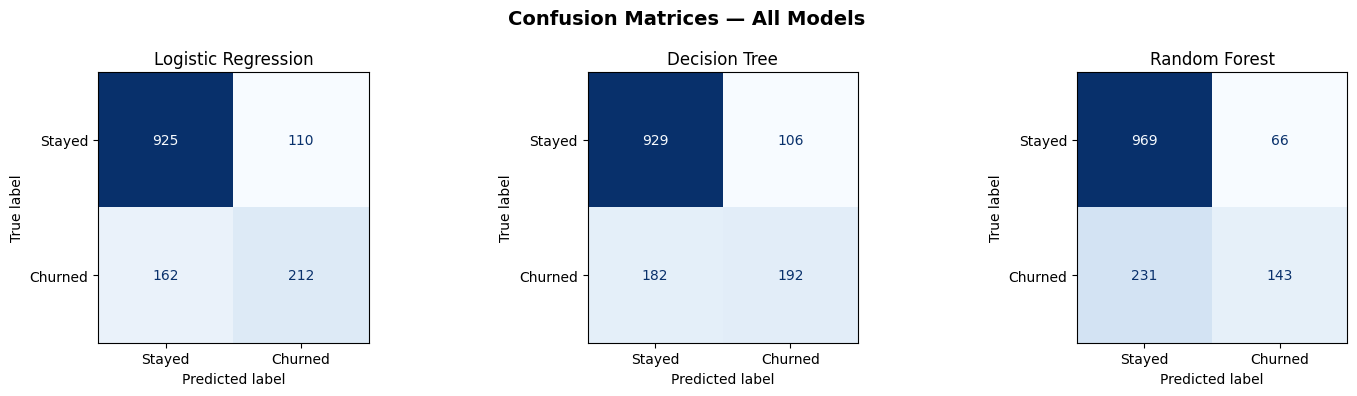

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')

models = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree', tree_pred),
    ('Random Forest', rf_pred)
]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Stayed', 'Churned'])
    disp.plot(ax=axes[idx], colorbar=False,
              cmap='Blues')
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

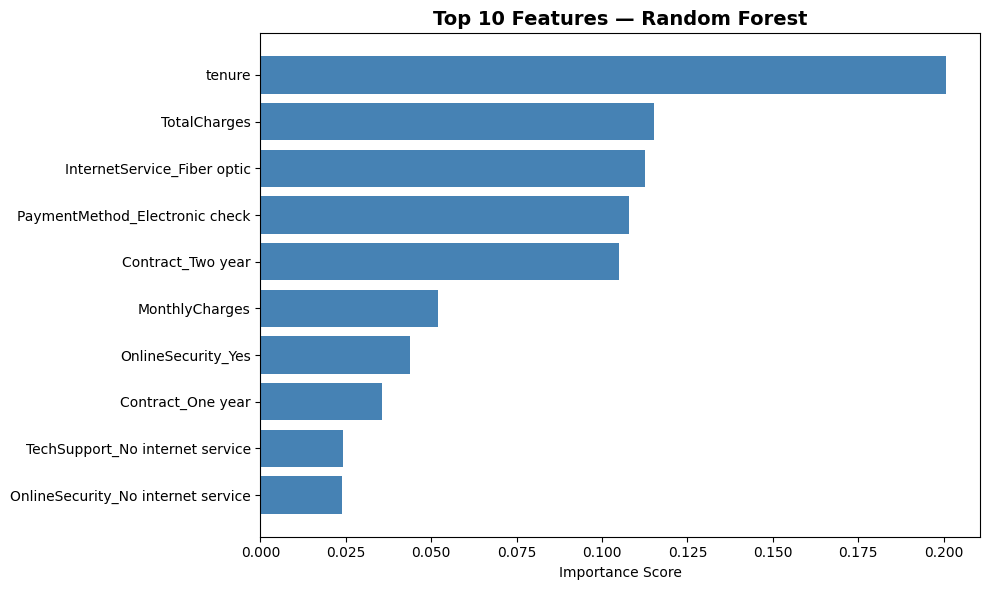


Top 10 Most Important Features:
                           Feature  Importance
                            tenure    0.200621
                      TotalCharges    0.115217
       InternetService_Fiber optic    0.112449
    PaymentMethod_Electronic check    0.107951
                 Contract_Two year    0.104978
                    MonthlyCharges    0.051847
                OnlineSecurity_Yes    0.043701
                 Contract_One year    0.035719
   TechSupport_No internet service    0.024205
OnlineSecurity_No internet service    0.023976


In [13]:
# Get feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='steelblue')
plt.title('Top 10 Features — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.to_string(index=False))

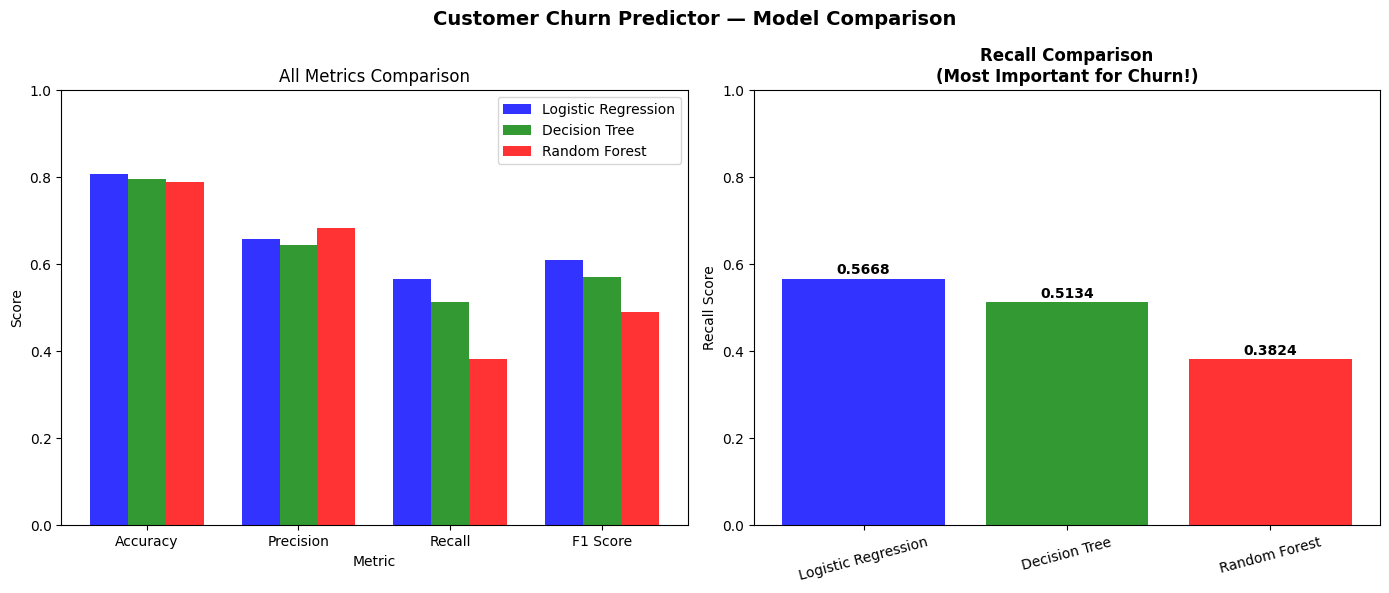

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Churn Predictor — Model Comparison',
             fontsize=14, fontweight='bold')

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['blue', 'green', 'red']
models_names = results_df['Model'].tolist()

# Plot 1 - All metrics comparison
x = np.arange(len(metrics_list))
width = 0.25

for idx, (model, color) in enumerate(
        zip(models_names, colors)):
    values = results_df[results_df['Model']==model][
        metrics_list].values[0]
    axes[0].bar(x + idx*width, values,
                width, label=model, color=color,
                alpha=0.8)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_list)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Plot 2 - Recall comparison (most important!)
axes[1].bar(models_names,
            results_df['Recall'],
            color=['blue', 'green', 'red'],
            alpha=0.8)
axes[1].set_title('Recall Comparison\n(Most Important for Churn!)',
                  fontweight='bold')
axes[1].set_ylabel('Recall Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

for idx, val in enumerate(results_df['Recall']):
    axes[1].text(idx, val + 0.01,
                 f'{val:.4f}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Save Logistic Regression as best model
with open('customer_churn_predictor.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Save scaler too - needed for future predictions!
with open('churn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved! ✅")
print("Scaler saved! ✅")

# Test loading and predicting
with open('customer_churn_predictor.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('churn_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Test prediction on first test sample
sample = X_test.iloc[0:1]
sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)
probability = loaded_model.predict_proba(sample_scaled)

print(f"\nSample prediction: {'Churn' if prediction[0]==1 else 'Stay'}")
print(f"Probability of churning: {probability[0][1]:.2%}")
print("\nModel loaded and working correctly! ✅")

Model saved! ✅
Scaler saved! ✅

Sample prediction: Stay
Probability of churning: 4.44%

Model loaded and working correctly! ✅


In [16]:
print("""
================================================
BUSINESS INSIGHTS — TELCO CUSTOMER CHURN ANALYSIS
================================================

1. BEST MODEL: Logistic Regression
   • Accuracy:  80.70%
   • Recall:    56.68%
   • F1 Score:  60.92%

2. CLASS IMBALANCE OBSERVED:
   • 73.5% of customers stayed
   • 26.5% of customers churned
   • Recall is more important than accuracy here!

3. KEY CHURN RISK FACTORS:
   • Month-to-month contract customers
     churn significantly more
   • Newer customers (low tenure) churn more
   • Long term customers are most loyal

4. MODEL COMPARISON INSIGHT:
   • Logistic Regression won — confirming
     relationships in this data are linear
   • Random Forest had highest precision (68.42%)
     but lowest recall (38.24%) — too conservative
   • Decision Tree balanced but outperformed
     by Logistic Regression overall

5. BUSINESS RECOMMENDATIONS:
   • TARGET month-to-month customers with
     upgrade offers to annual contracts
   • FOCUS retention efforts on customers
     in first 12 months of tenure
   • USE this model to score ALL customers
     monthly and prioritise at-risk ones
   • OFFER loyalty rewards to long-term
     customers to maintain retention

6. FINANCIAL IMPACT:
   • Model correctly identifies 56.68% of
     churning customers BEFORE they leave
   • Each retained customer saves the company
     their full lifetime revenue value
   • Early intervention is always cheaper
     than customer acquisition!

7. FUTURE IMPROVEMENTS:
   • Collect more features — reason for
     cancellation, customer satisfaction scores
   • Try XGBoost or Neural Networks for
     potentially higher recall
   • Implement monthly re-training as new
     customer data arrives
================================================
""")


BUSINESS INSIGHTS — TELCO CUSTOMER CHURN ANALYSIS

1. BEST MODEL: Logistic Regression
   • Accuracy:  80.70%
   • Recall:    56.68%
   • F1 Score:  60.92%

2. CLASS IMBALANCE OBSERVED:
   • 73.5% of customers stayed
   • 26.5% of customers churned
   • Recall is more important than accuracy here!

3. KEY CHURN RISK FACTORS:
   • Month-to-month contract customers 
     churn significantly more
   • Newer customers (low tenure) churn more
   • Long term customers are most loyal

4. MODEL COMPARISON INSIGHT:
   • Logistic Regression won — confirming
     relationships in this data are linear
   • Random Forest had highest precision (68.42%)
     but lowest recall (38.24%) — too conservative
   • Decision Tree balanced but outperformed
     by Logistic Regression overall

5. BUSINESS RECOMMENDATIONS:
   • TARGET month-to-month customers with 
     upgrade offers to annual contracts
   • FOCUS retention efforts on customers 
     in first 12 months of tenure
   • USE this model to score AL